In [1]:
import numpy as np

path = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\attn_npz\10x\vision_concept_gated\FA_PT_k=0\FA 47 B1_eval.npz"
d = np.load(path, allow_pickle=True)

print(d.files)
coords = d["coords"]          # (N, 2)
attn = d["attn"]              # (N,)
p_pt = float(d["p_pt"][0])
y_true = int(d["y_true"][0])

['slide_id', 'y_true', 'p_pt', 'coords', 'Xc', 'attn', 'attn_vision', 'attn_concept', 'attn_logits', 'concept_mean', 'concept_attn_weighted']


In [2]:
attn_vision = d["attn_vision"]     # (N,)
attn_concept = d["attn_concept"]   # (N,)
Xc = d["Xc"]                       # (N, C)

compare coga attn comp

In [9]:
import numpy as np

d = np.load(path, allow_pickle=True)

Xc = d["Xc"]          # (N, C)
attn = d["attn"]      # (N,)

concept_scores = (attn[:, None] * Xc).sum(axis=0)  # (C,)
top_idx = np.argmax(concept_scores)

print("Top concept index:", top_idx)
print("Score:", concept_scores[top_idx])

Top concept index: 14
Score: 0.48100278


In [10]:
top_concept_per_patch = Xc.argmax(axis=1)   # (N,)
top_score_per_patch = Xc.max(axis=1)

In [11]:
i = np.argmax(attn)  # most important patch

print("Patch index:", i)
print("Top concept:", top_concept_per_patch[i])
print("Score:", top_score_per_patch[i])

Patch index: 4167
Top concept: 6
Score: 0.46076643


In [13]:
k = 5
idx = np.argsort(-concept_scores)[:k]

for i in idx:
    print(i, concept_scores[i])

14 0.48100278
15 0.38959873
18 0.34359533
4 0.3432276
10 0.34112874


USE THIS for cogamil attn maps

['slide_id', 'y_true', 'p_pt', 'coords', 'Xc', 'attn', 'attn_vision', 'attn_concept', 'attn_logits', 'concept_mean', 'concept_attn_weighted']


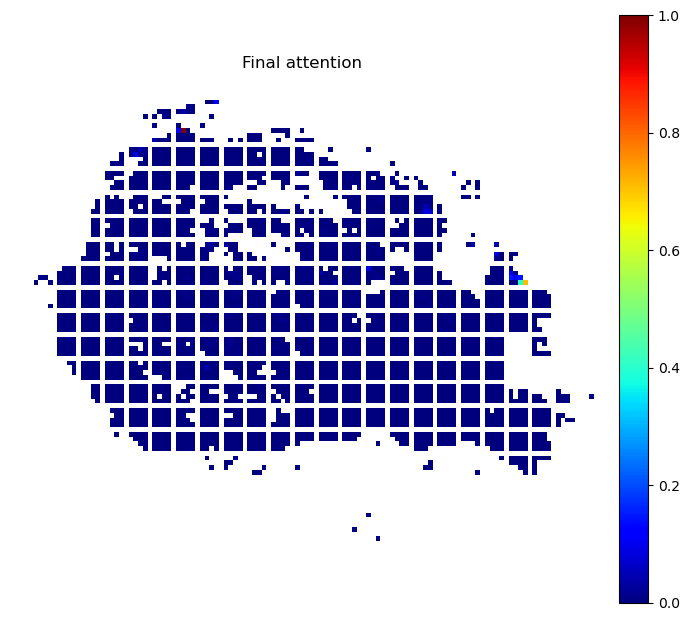

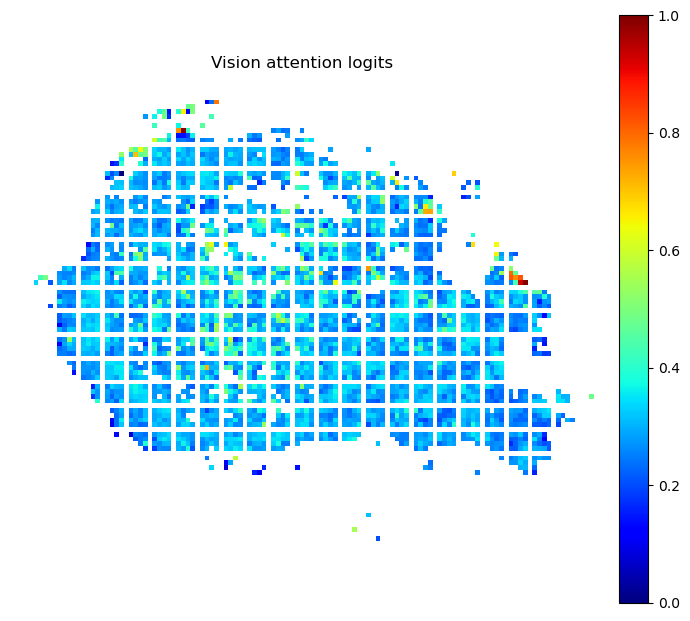

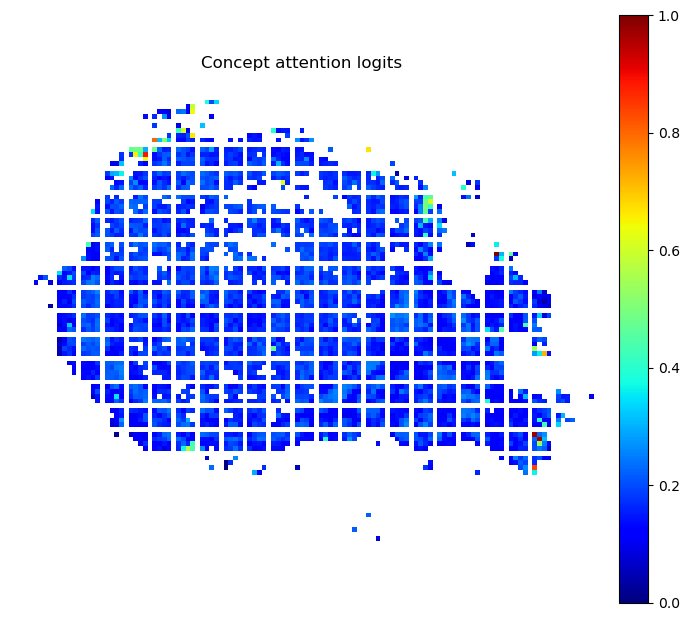

Top concept index: 14
Score: 0.32756445
Patch index: 25
Top concept: 46
Score: 0.3251355
14 0.32756445
4 0.28761637
17 0.25323206
15 0.24437647
6 0.22161156


In [6]:
# %%
import numpy as np
import matplotlib.pyplot as plt

path = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\attn_npz\10x\vision_concept_gated\FA_PT_k=2\FA 72 B1_eval.npz"
d = np.load(path, allow_pickle=True)

print(d.files)
coords = d["coords"]          # (N, 2)
attn = d["attn"]              # (N,)
p_pt = float(d["p_pt"][0])
y_true = int(d["y_true"][0])

# %%
attn_vision = d["attn_vision"]     # (N,)
attn_concept = d["attn_concept"]   # (N,)
Xc = d["Xc"]                       # (N, C)

def scores_to_patch_grid(coords, scores, patch_size=224):
    coords = coords.astype(int)
    scores = scores.astype(float)

    gx = coords[:, 0] // patch_size
    gy = coords[:, 1] // patch_size

    w = gx.max() + 1
    h = gy.max() + 1

    canvas = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)

    for x, y, s in zip(gx, gy, scores):
        canvas[y, x] += s
        count[y, x] += 1

    valid_mask = count > 0
    count[count == 0] = 1
    canvas /= count

    return canvas, valid_mask

# %%
def minmax01_valid(x, valid_mask):
    x = x.astype(np.float32).copy()

    if not np.any(valid_mask):
        return np.full_like(x, np.nan, dtype=np.float32)

    lo = np.nanmin(x[valid_mask])
    hi = np.nanmax(x[valid_mask])

    if hi <= lo:
        out = np.zeros_like(x, dtype=np.float32)
    else:
        out = (x - lo) / (hi - lo)

    out[~valid_mask] = np.nan
    return out

# %%
def plot_heatmap(h, title, cmap_name="jet", figsize=(8, 8)):
    cmap = plt.colormaps[cmap_name].copy()
    cmap.set_bad(color="white")   # NaN background -> white

    fig, ax = plt.subplots(figsize=figsize)
    # im = ax.imshow(h, cmap=cmap, vmin=0, vmax=1)
    im = ax.imshow(h, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

# %% [markdown]
# compare coga attn comp

# %%
heat_final_raw, valid_mask_final = scores_to_patch_grid(coords, d["attn"], patch_size=224)
heat_vis_raw, valid_mask_vis = scores_to_patch_grid(coords, d["attn_vision"], patch_size=224)
heat_concept_raw, valid_mask_concept = scores_to_patch_grid(coords, d["attn_concept"], patch_size=224)

heat_final = minmax01_valid(heat_final_raw, valid_mask_final)
heat_vis = minmax01_valid(heat_vis_raw, valid_mask_vis)
heat_concept = minmax01_valid(heat_concept_raw, valid_mask_concept)

# %%
for title, h in [
    ("Final attention", heat_final),
    ("Vision attention logits", heat_vis),
    ("Concept attention logits", heat_concept),
]:
    plot_heatmap(h, title, cmap_name="jet", figsize=(7, 7))

# %%
d = np.load(path, allow_pickle=True)

Xc = d["Xc"]          # (N, C)
attn = d["attn"]      # (N,)

concept_scores = (attn[:, None] * Xc).sum(axis=0)  # (C,)
top_idx = np.argmax(concept_scores)

print("Top concept index:", top_idx)
print("Score:", concept_scores[top_idx])

# %%
top_concept_per_patch = Xc.argmax(axis=1)   # (N,)
top_score_per_patch = Xc.max(axis=1)

# %%
i = np.argmax(attn)  # most important patch

print("Patch index:", i)
print("Top concept:", top_concept_per_patch[i])
print("Score:", top_score_per_patch[i])

# %%
k = 5
idx = np.argsort(-concept_scores)[:k]

for i in idx:
    print(i, concept_scores[i])

In [10]:
attn_c_mass = np.sum(attn_concept)
attn_v_mass = np.sum(attn_vision)

In [11]:
print(f"Concept attn mass: {attn_c_mass:.4f}")
print(f"Vision attn mass: {attn_v_mass:.4f}")

Concept attn mass: -144.4744
Vision attn mass: 6.6192


In [12]:
top_final = set(np.argsort(-attn)[:20])
top_vis   = set(np.argsort(-attn_vision)[:20])
top_con   = set(np.argsort(-attn_concept)[:20])

USE THIS vision-only abmil

In [8]:
import numpy as np
import matplotlib.pyplot as plt
path_abmil = r"C:\Users\Vivian\Documents\CONCH\test_text_encoder\attn_npz\10x\vision_abmil\FA_PT_k=2\FA 72 B1_eval.npz"
d2 = np.load(path_abmil, allow_pickle=True)

print(d2.files)
coords = d2["coords"]          # (N, 2)
attn = d2["attn"]              # (N,)
p_pt = float(d2["p_pt"][0])
y_true = int(d2["y_true"][0])

['slide_id', 'y_true', 'p_pt', 'coords', 'attn', 'attn_logits']


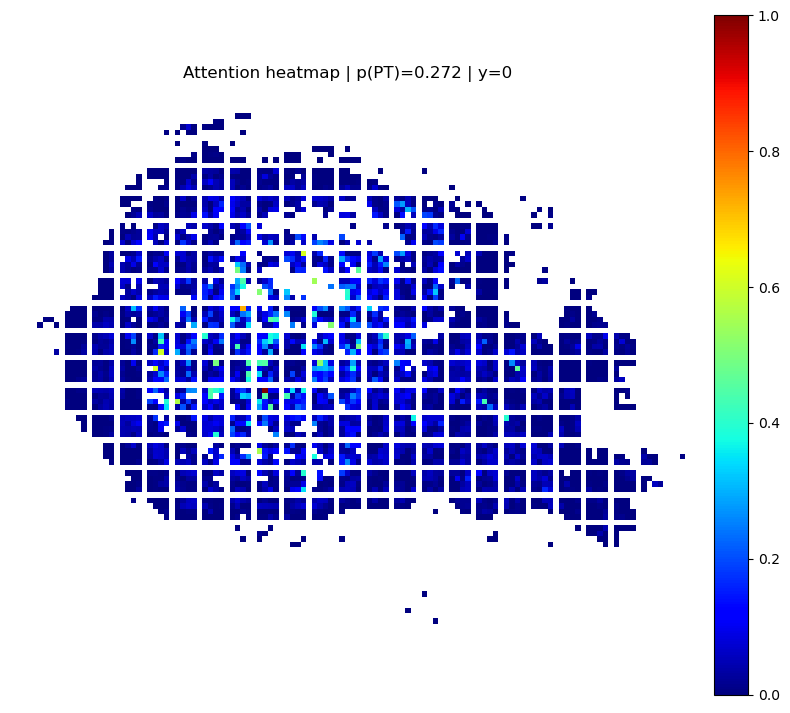

In [9]:
def scores_to_patch_grid(coords, scores, patch_size=224):
    coords = coords.astype(int)
    scores = scores.astype(float)

    gx = coords[:, 0] // patch_size
    gy = coords[:, 1] // patch_size

    w = gx.max() + 1
    h = gy.max() + 1

    canvas = np.zeros((h, w), dtype=np.float32)
    count = np.zeros((h, w), dtype=np.float32)

    for x, y, s in zip(gx, gy, scores):
        canvas[y, x] += s
        count[y, x] += 1

    valid_mask = count > 0
    count[count == 0] = 1
    canvas /= count

    return canvas, valid_mask

def minmax01_valid(x, valid_mask):
    x = x.astype(np.float32).copy()

    if not np.any(valid_mask):
        return np.full_like(x, np.nan, dtype=np.float32)

    lo = np.nanmin(x[valid_mask])
    hi = np.nanmax(x[valid_mask])

    if hi <= lo:
        out = np.zeros_like(x, dtype=np.float32)
    else:
        out = (x - lo) / (hi - lo)

    out[~valid_mask] = np.nan
    return out

def plot_heatmap(h, title, cmap_name="jet", figsize=(8, 8)):
    cmap = plt.colormaps[cmap_name].copy()
    cmap.set_bad(color="white")   # NaN background -> white

    fig, ax = plt.subplots(figsize=figsize)
    # im = ax.imshow(h, cmap=cmap, vmin=0, vmax=1)
    im = ax.imshow(h, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(title)
    ax.axis("off")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()

heat, valid_mask = scores_to_patch_grid(coords, attn, patch_size=224)
heat_disp = minmax01_valid(heat, valid_mask)

plot_heatmap(
    heat_disp,
    f"Attention heatmap | p(PT)={p_pt:.3f} | y={y_true}"
)
